<a href="https://colab.research.google.com/github/Moaazhe74/CIFAR10-CNN-AE-VAE-GANs/blob/main/CIFAR10_(Deep_Learning_Project).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***1. Project Introduction***

This project applies different Deep Learning techniques to the CIFAR-10 image dataset.  
The objective is to build a complete Deep Learning portfolio that includes image classification, optimizer comparison, image reconstruction, and image generation.

The project consists of three main parts:

1. **Image Classification**
   - Build a Convolutional Neural Network (CNN) to classify CIFAR-10 images into 10 different classes.
   - Train the same CNN architecture using different optimizers.
   - Compare the performance of Adam and SGD with Momentum.

2. **Image Reconstruction**
   - Build a Convolutional Autoencoder or Variational Autoencoder.
   - Compress the input images into a latent representation.
   - Reconstruct the original images and evaluate the reconstruction quality.

3. **Image Generation**
   - Use a generative model such as a Variational Autoencoder or GAN.
   - Generate new images similar to the CIFAR-10 dataset.
   - Compare original, reconstructed, and generated images.

The models will be evaluated using training loss, validation loss, accuracy, reconstruction loss, and visual inspection of the generated images.

---

## Dataset

The **CIFAR-10 dataset** contains 60,000 colored images with a size of `32 × 32` pixels.

The dataset is divided into:

- 50,000 training images.
- 10,000 testing images.
- 10 different image classes.

The classes are:

`Airplane`, `Automobile`, `Bird`, `Cat`, `Deer`, `Dog`, `Frog`, `Horse`, `Ship`, and `Truck`.

# ***2. Imports and Setup***

In [117]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tarfile
import pickle

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error,classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models,layers,callbacks
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam,SGD

import warnings
warnings.filterwarnings('ignore')

# ***3. Load CIFAR-10 Dataset***

In [73]:
DataSetGoogleDrivePath = '/content/drive/MyDrive/DataSets/cifar-10-python.tar.gz'

extract_dir = "/content/drive/MyDrive/DataSets"

dataset_dir = os.path.join(
    extract_dir,
    "cifar-10-batches-py"
)

if os.path.exists(dataset_dir):
    print("Dataset is already extracted.")
    print("Dataset directory:", dataset_dir)

else:
    print("Extracting CIFAR-10 dataset...")

    with tarfile.open(DataSetGoogleDrivePath, mode="r:gz") as tar:
        tar.extractall(path=extract_dir)

    print("Dataset extracted successfully.")
    print("Dataset directory:", dataset_dir)

Dataset is already extracted.
Dataset directory: /content/drive/MyDrive/DataSets/cifar-10-batches-py


In [74]:
def load_cifar_batch(file_path):

    with open(file_path, "rb") as file:
        batch = pickle.load(file, encoding="bytes")

    images = batch[b"data"]
    labels = batch[b"labels"]


    images = images.reshape(-1, 3, 32, 32)


    images = images.transpose(0, 2, 3, 1)


    labels = np.array(labels).reshape(-1, 1)

    return images, labels



In [75]:
train_images = []
train_labels = []

for batch_number in range(1, 6):

    batch_path = os.path.join(
        dataset_dir,
        f"data_batch_{batch_number}"
    )

    images, labels = load_cifar_batch(batch_path)

    train_images.append(images)
    train_labels.append(labels)

    print(
        f"Batch {batch_number} loaded:",
        images.shape,
        labels.shape
    )
x_train = np.concatenate(train_images, axis=0)
y_train = np.concatenate(train_labels, axis=0)



test_batch_path = os.path.join(dataset_dir,"test_batch")
x_test, y_test = load_cifar_batch(test_batch_path)

Batch 1 loaded: (10000, 32, 32, 3) (10000, 1)
Batch 2 loaded: (10000, 32, 32, 3) (10000, 1)
Batch 3 loaded: (10000, 32, 32, 3) (10000, 1)
Batch 4 loaded: (10000, 32, 32, 3) (10000, 1)
Batch 5 loaded: (10000, 32, 32, 3) (10000, 1)


In [76]:
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


In [77]:
print("\nImage data type:", x_train.dtype)
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())


Image data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


In [78]:
meta_path = os.path.join(dataset_dir, "batches.meta")

with open(meta_path, "rb") as file:
    meta_data = pickle.load(file, encoding="bytes")

class_names = [
    class_name.decode("utf-8")
    for class_name in meta_data[b"label_names"]
]

print("CIFAR-10 Classes:\n")

for label, class_name in enumerate(class_names):
    print(f"{label}: {class_name}")

CIFAR-10 Classes:

0: airplane
1: automobile
2: bird
3: cat
4: deer
5: dog
6: frog
7: horse
8: ship
9: truck


# ***4. Data Exploration***

## **4.1 Representing 20 random samples**

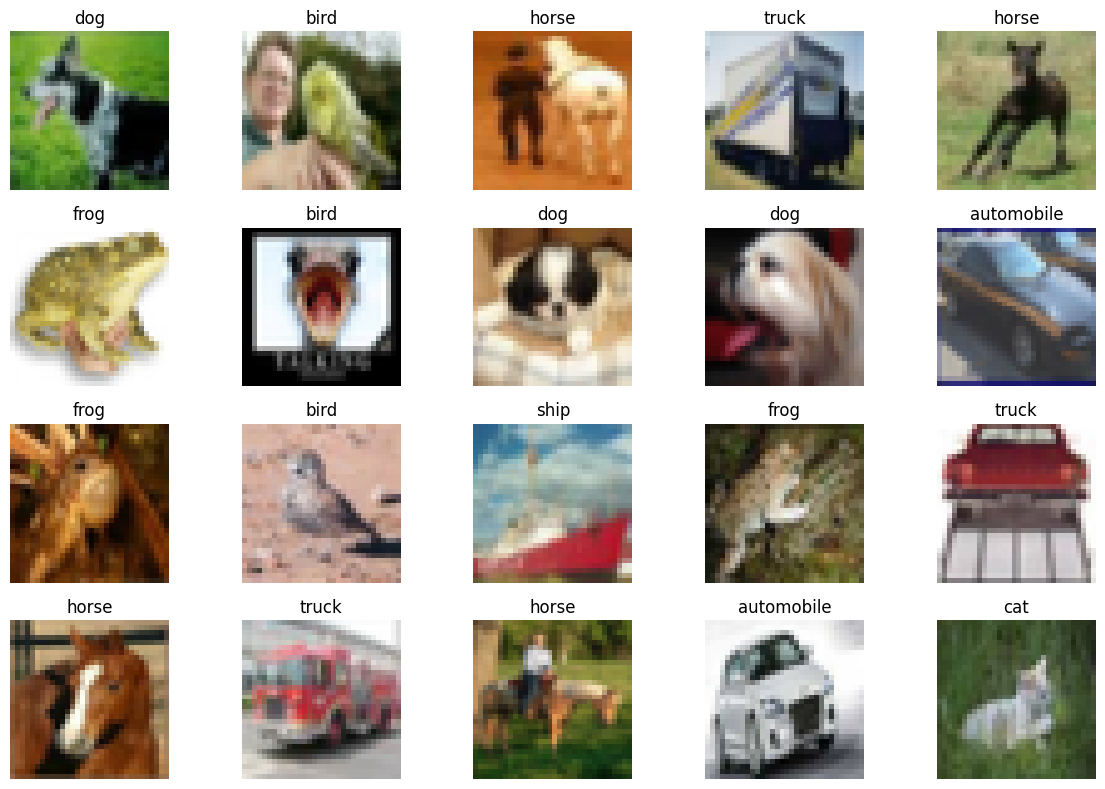

In [79]:
number_of_images = 20

random_indices = np.random.choice(
    len(x_train),
    size=number_of_images,
    replace=False
)

plt.figure(figsize=(12, 8))

for position, image_index in enumerate(random_indices):

    plt.subplot(4, 5, position + 1)

    plt.imshow(x_train[image_index])

    label = y_train[image_index][0]

    plt.title(class_names[label])

    plt.axis("off")

plt.tight_layout()
plt.show()

## **4.2 Classes Distripution**

In [80]:
unique_labels, class_counts = np.unique(
    y_train,
    return_counts=True
)

print("Training class distribution:\n")

for label, count in zip(unique_labels, class_counts):
    print(f"{label} - {class_names[label]}: {count} images")

Training class distribution:

0 - airplane: 5000 images
1 - automobile: 5000 images
2 - bird: 5000 images
3 - cat: 5000 images
4 - deer: 5000 images
5 - dog: 5000 images
6 - frog: 5000 images
7 - horse: 5000 images
8 - ship: 5000 images
9 - truck: 5000 images


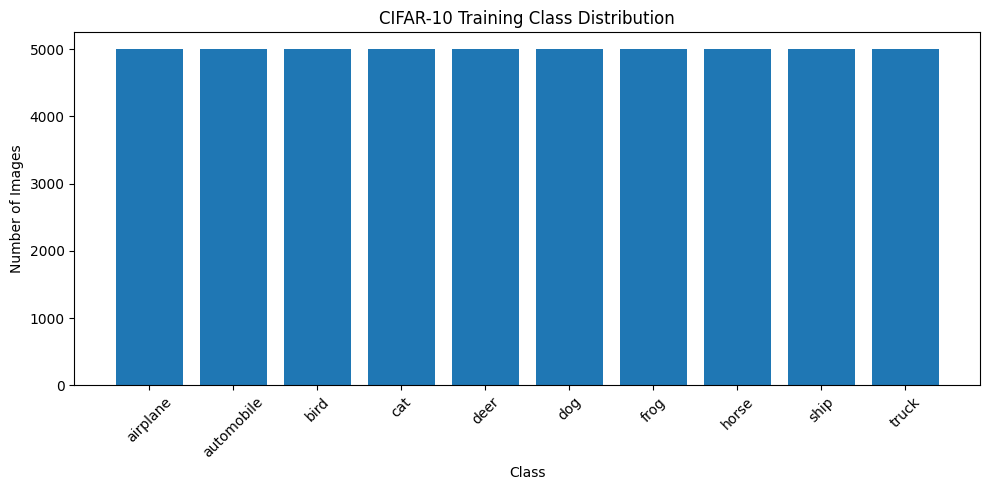

In [81]:
plt.figure(figsize=(10, 5))

plt.bar(class_names, class_counts)

plt.title("CIFAR-10 Training Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ***5. Data Preprocessing***

In [82]:
x_train_original = x_train.copy()
x_test_original = x_test.copy()

y_train_original = y_train.copy()
y_test_original = y_test.copy()

## **5.1 Normalization & change dtype**

In [83]:
x_train=x_train.astype('float32')
y_train=y_train.astype('float32')

x_train=x_train/255.0
x_test=x_test/255.0

## **5.2 Labels Reshape**

In [84]:
y_test=y_test.reshape(-1)
y_train=y_train.reshape(-1)

## **5.3 Validation Set Separation**

In [85]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

# ***6. CNN Classification Model***

## **6.1 Build CNN model**

In [86]:
input_shape = (32, 32, 3)
number_of_classes = len(class_names)

def build_cnn_model():
    model = models.Sequential(
        [
            # Input layer
            layers.Input(shape=input_shape),

            # First convolutional block
            layers.Conv2D(
                filters=32,
                kernel_size=(3, 3),
                padding="same",
                activation="relu"
            ),

            layers.MaxPooling2D(
                pool_size=(2, 2)
            ),

            layers.Dropout(0.25),

            # Second convolutional block
            layers.Conv2D(
                filters=64,
                kernel_size=(3, 3),
                padding="same",
                activation="relu"
            ),

            layers.MaxPooling2D(
                pool_size=(2, 2)
            ),

            layers.Dropout(0.25),

            # Third convolutional block
            layers.Conv2D(
                filters=128,
                kernel_size=(3, 3),
                padding="same",
                activation="relu"
            ),

            layers.MaxPooling2D(
                pool_size=(2, 2)
            ),

            layers.Dropout(0.25),

            # Convert feature maps into one vector
            layers.Flatten(),

            # Fully connected layer
            layers.Dense(
                units=128,
                activation="relu"
            ),

            layers.Dropout(0.5),

            # Output layer
            layers.Dense(
                units=number_of_classes,
                activation="softmax"
            )
        ],
        name="CIFAR10_CNN"
    )

    return model

In [87]:
cnn_template = build_cnn_model()

print("CNN model created successfully.")

CNN model created successfully.


In [88]:
cnn_template.summary()


Model: "CIFAR10_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

## **6.2 construct constant intial weights**

In [89]:
initial_weights = cnn_template.get_weights()

print("Initial model weights saved.")

Initial model weights saved.


# ***7. Adam Training***

## **7.1 build ADAM model & add intial weghts**

In [90]:
adam_model = build_cnn_model()

adam_model.set_weights(initial_weights)

print("Adam model created with the same initial weights.")

Adam model created with the same initial weights.


## **7.2 construct optimizer ,loss & metrics for ADAM model**

In [91]:
adam_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Adam model compiled successfully.")

Adam model compiled successfully.


## **7.3 construct early stopping for ADAM model**

In [92]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

## **7.4 ADAM model fitting**

In [93]:
adam_history = adam_model.fit(
    x_train,
    y_train,
    epochs=100,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.3385 - loss: 1.7877 - val_accuracy: 0.4916 - val_loss: 1.4064
Epoch 2/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4882 - loss: 1.4280 - val_accuracy: 0.5714 - val_loss: 1.1878
Epoch 3/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5436 - loss: 1.2753 - val_accuracy: 0.6248 - val_loss: 1.0606
Epoch 4/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5783 - loss: 1.1860 - val_accuracy: 0.6676 - val_loss: 0.9775
Epoch 5/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6075 - loss: 1.1075 - val_accuracy: 0.6776 - val_loss: 0.9088
Epoch 6/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6325 - loss: 1.0516 - val_accuracy: 0.6972 - val_loss: 0.8481
Epoch 7/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6483 - loss: 1.0025 - val_accuracy: 0.7020 - val_loss: 0.8424
Epoch 8/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6658 - loss: 0.9651 - val_ac

## **7.5 initial evaluation and representaion for ADAM model scores**

In [94]:
adam_test_loss, adam_test_accuracy = adam_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Adam Test Loss:", adam_test_loss)
print("Adam Test Accuracy:", adam_test_accuracy)

Adam Test Loss: 0.6092845797538757
Adam Test Accuracy: 0.7896000146865845


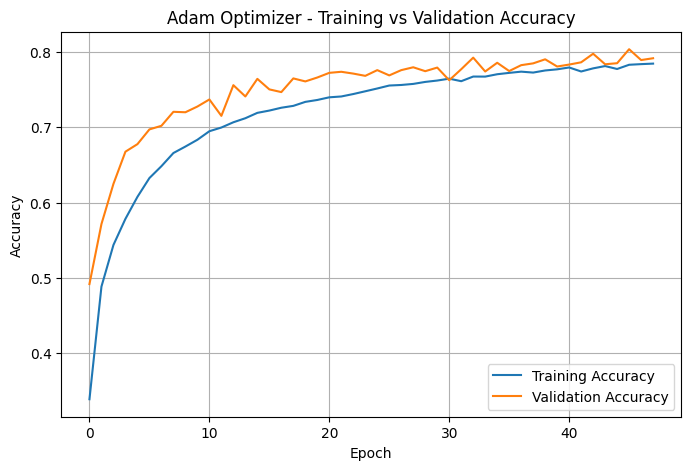

In [95]:
plt.figure(figsize=(8, 5))

plt.plot(adam_history.history["accuracy"], label="Training Accuracy")
plt.plot(adam_history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Adam Optimizer - Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)
plt.show()

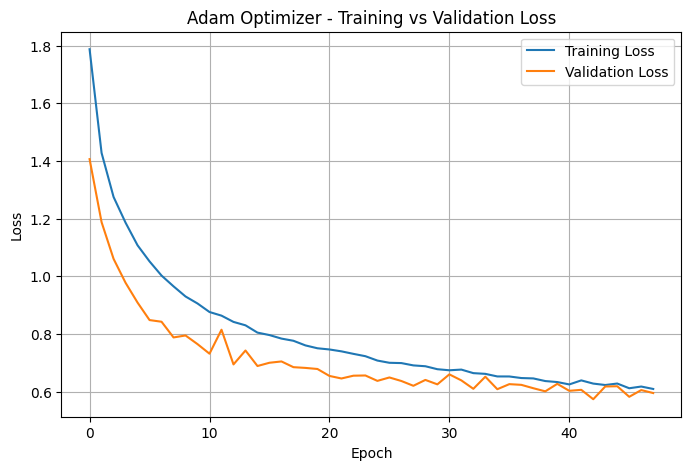

In [96]:
plt.figure(figsize=(8, 5))

plt.plot(adam_history.history["loss"], label="Training Loss")
plt.plot(adam_history.history["val_loss"], label="Validation Loss")

plt.title("Adam Optimizer - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)
plt.show()

# ***8. SGD with Momentum Training***

## **8.1 build SGD with momentum model & add intial weghts**

In [98]:
sgd_model = build_cnn_model()

sgd_model.set_weights(initial_weights)

print("SGD model created with the same initial weights.")

SGD model created with the same initial weights.


## **8.2 construct optimizer ,loss & metrics for SGD with momentum model**

In [99]:
sgd_model.compile(
    optimizer=SGD(
        learning_rate=0.01,
        momentum=0.9
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("SGD model compiled successfully.")

SGD model compiled successfully.


8.3 construct early stopping for SGD with momentum model

In [100]:
sgd_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

## **8.4 SGD with momentum model fitting**

In [101]:
sgd_history = sgd_model.fit(
    x_train,
    y_train,
    epochs=100,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[sgd_early_stopping],
    verbose=1
)

Epoch 1/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.2631 - loss: 1.9933 - val_accuracy: 0.3562 - val_loss: 1.7677
Epoch 2/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4027 - loss: 1.6311 - val_accuracy: 0.5020 - val_loss: 1.4081
Epoch 3/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4650 - loss: 1.4684 - val_accuracy: 0.5286 - val_loss: 1.3030
Epoch 4/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5130 - loss: 1.3487 - val_accuracy: 0.5852 - val_loss: 1.1643
Epoch 5/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5504 - loss: 1.2596 - val_accuracy: 0.6098 - val_loss: 1.1231
Epoch 6/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5793 - loss: 1.1824 - val_accuracy: 0.6328 - val_loss: 1.0364
Epoch 7/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5993 - loss: 1.1272 - val_accuracy: 0.6586 - val_loss: 0.9523
Epoch 8/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6187 - loss: 1.0788 - val_ac

## **8.5 initial evaluation and representaion for SGD with momentum model scores**

In [102]:
sgd_test_loss, sgd_test_accuracy = sgd_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("SGD Test Loss:", sgd_test_loss)
print("SGD Test Accuracy:", sgd_test_accuracy)

SGD Test Loss: 0.6816239356994629
SGD Test Accuracy: 0.7684999704360962


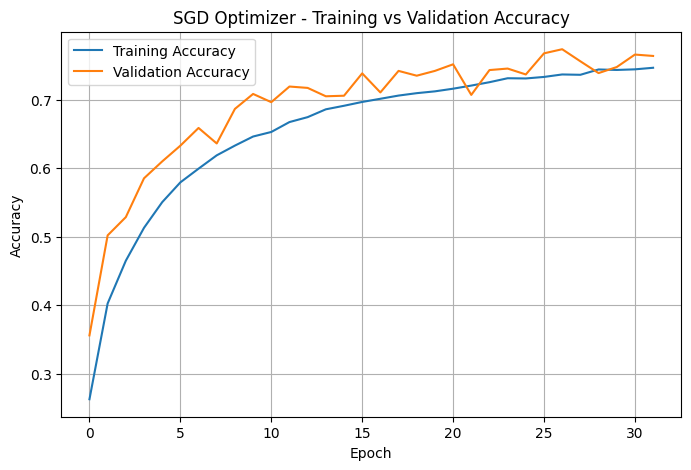

In [103]:
plt.figure(figsize=(8, 5))

plt.plot(
    sgd_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    sgd_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("SGD Optimizer - Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)
plt.show()

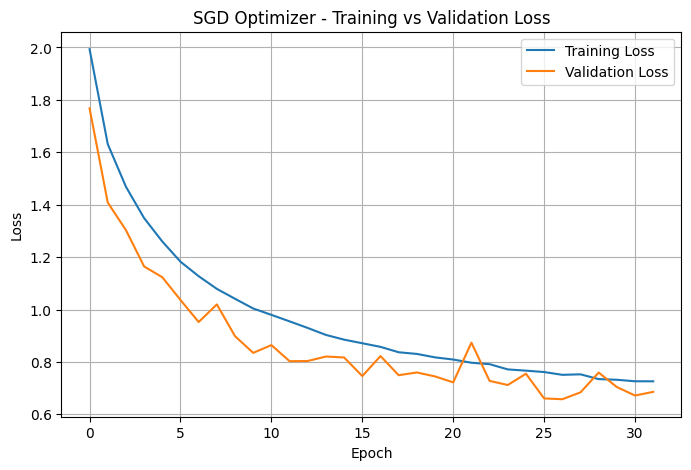

In [104]:
plt.figure(figsize=(8, 5))

plt.plot(
    sgd_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    sgd_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("SGD Optimizer - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)
plt.show()

# ***9. Optimizer Comparison***

## **9.1 Results comparison**

In [105]:
optimizer_results = pd.DataFrame({
    "Optimizer": ["Adam", "SGD with Momentum"],
    "Test Loss": [adam_test_loss, sgd_test_loss],
    "Test Accuracy": [adam_test_accuracy, sgd_test_accuracy]
})

optimizer_results

,Optimizer,Test Loss,Test Accuracy
0,Adam,0.609285,0.7896
1,SGD with Momentum,0.681624,0.7685


## **9.2 Test Accuracy Comparison**

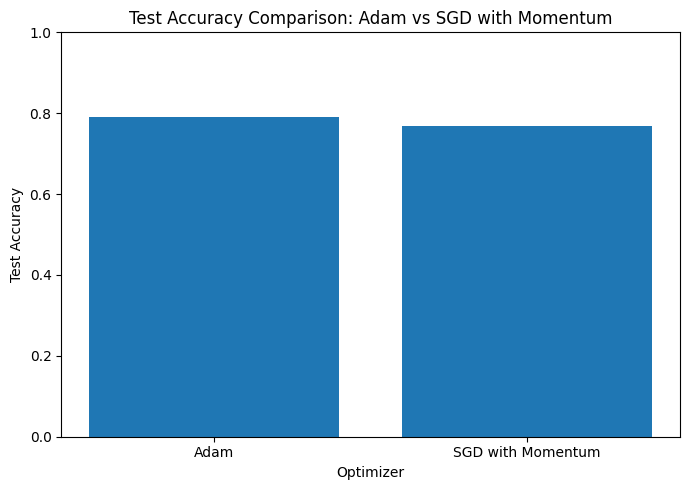

In [106]:
plt.figure(figsize=(7, 5))

plt.bar(
    optimizer_results["Optimizer"],
    optimizer_results["Test Accuracy"]
)

plt.title("Test Accuracy Comparison: Adam vs SGD with Momentum")
plt.xlabel("Optimizer")
plt.ylabel("Test Accuracy")

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

## **9.3 Test Loss Comparison**

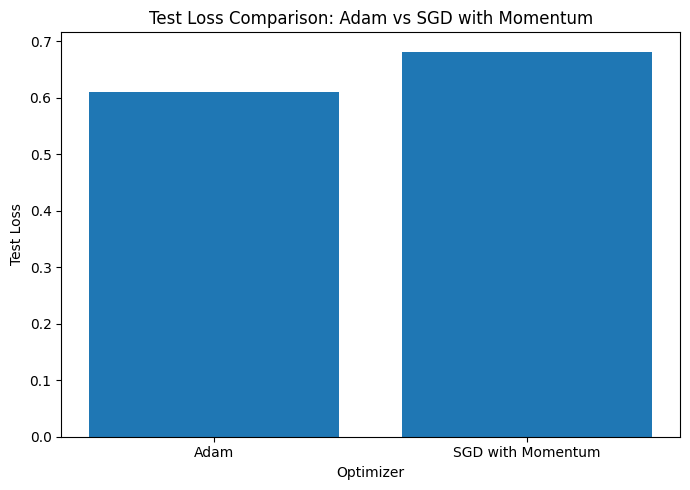

In [107]:
plt.figure(figsize=(7, 5))

plt.bar(
    optimizer_results["Optimizer"],
    optimizer_results["Test Loss"]
)

plt.title("Test Loss Comparison: Adam vs SGD with Momentum")
plt.xlabel("Optimizer")
plt.ylabel("Test Loss")

plt.tight_layout()
plt.show()

## **9.4 Validation Accuracy Comparison**

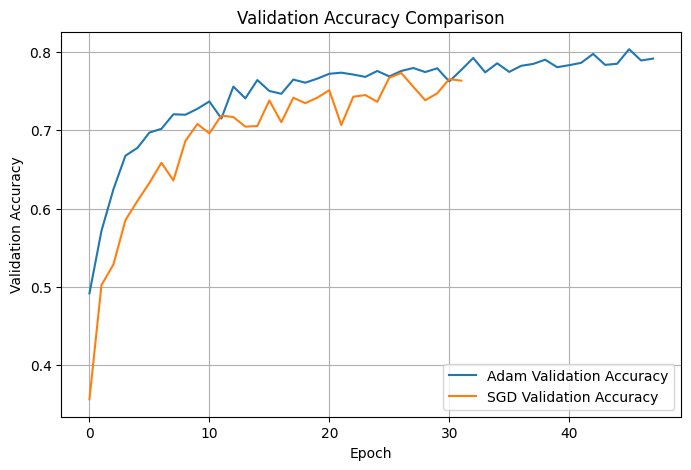

In [108]:
plt.figure(figsize=(8, 5))

plt.plot(
    adam_history.history["val_accuracy"],
    label="Adam Validation Accuracy"
)

plt.plot(
    sgd_history.history["val_accuracy"],
    label="SGD Validation Accuracy"
)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.legend()
plt.grid(True)
plt.show()

## **9.5 Validation Loss Comparison**

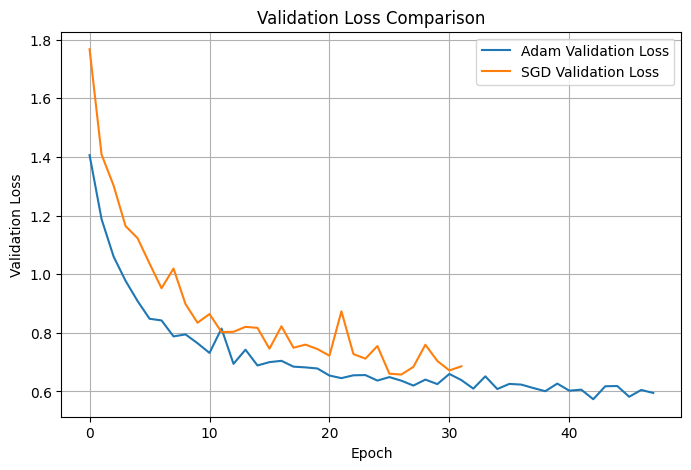

In [109]:
plt.figure(figsize=(8, 5))

plt.plot(
    adam_history.history["val_loss"],
    label="Adam Validation Loss"
)

plt.plot(
    sgd_history.history["val_loss"],
    label="SGD Validation Loss"
)

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.legend()
plt.grid(True)
plt.show()

## **9.6 Best optimizer is ADAM**

In [110]:
best_optimizer_index = optimizer_results["Test Accuracy"].idxmax()

best_optimizer = optimizer_results.loc[best_optimizer_index, "Optimizer"]
best_accuracy = optimizer_results.loc[best_optimizer_index, "Test Accuracy"]
best_loss = optimizer_results.loc[best_optimizer_index, "Test Loss"]

print("Best Optimizer:", best_optimizer)
print("Best Test Accuracy:", best_accuracy)
print("Best Test Loss:", best_loss)

Best Optimizer: Adam
Best Test Accuracy: 0.7896000146865845
Best Test Loss: 0.6092845797538757


## **9.7 apply ADAM model classification on test data**

### **9.7.1 ADAM model predication**

In [113]:
y_pred_probabilities = adam_model.predict(x_test)

print("Prediction probabilities shape:", y_pred_probabilities.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Prediction probabilities shape: (10000, 10)


In [114]:
y_pred = np.argmax(y_pred_probabilities, axis=1)

print("Predicted labels shape:", y_pred.shape)
print("First 10 predicted labels:", y_pred[:10])
print("First 10 true labels:", y_test[:10])

Predicted labels shape: (10000,)
First 10 predicted labels: [5 8 8 8 6 6 9 6 3 9]
First 10 true labels: [3 8 8 0 6 6 1 6 3 1]


### **9.7.2 ADAM model classification report**

In [115]:
report = classification_report(
    y_test,
    y_pred,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

    airplane       0.83      0.80      0.81      1000
  automobile       0.89      0.91      0.90      1000
        bird       0.71      0.69      0.70      1000
         cat       0.61      0.64      0.62      1000
        deer       0.73      0.76      0.74      1000
         dog       0.70      0.68      0.69      1000
        frog       0.84      0.85      0.85      1000
       horse       0.87      0.80      0.83      1000
        ship       0.86      0.90      0.88      1000
       truck       0.87      0.87      0.87      1000

    accuracy                           0.79     10000
   macro avg       0.79      0.79      0.79     10000
weighted avg       0.79      0.79      0.79     10000



<Figure size 1000x800 with 0 Axes>

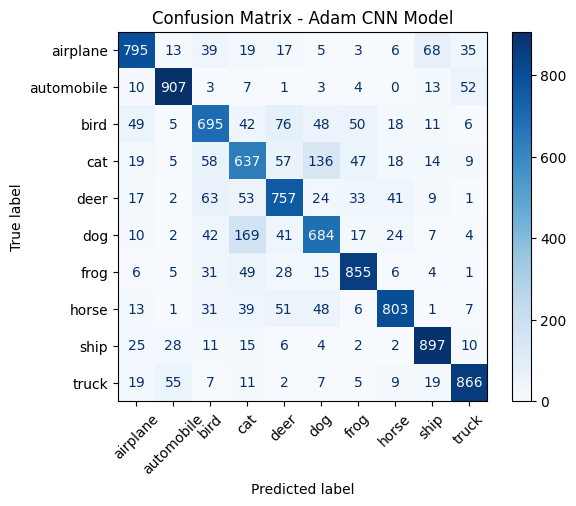

In [118]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    xticks_rotation=45,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix - Adam CNN Model")
plt.show()

### **9.7.3 represinting 20 random images**

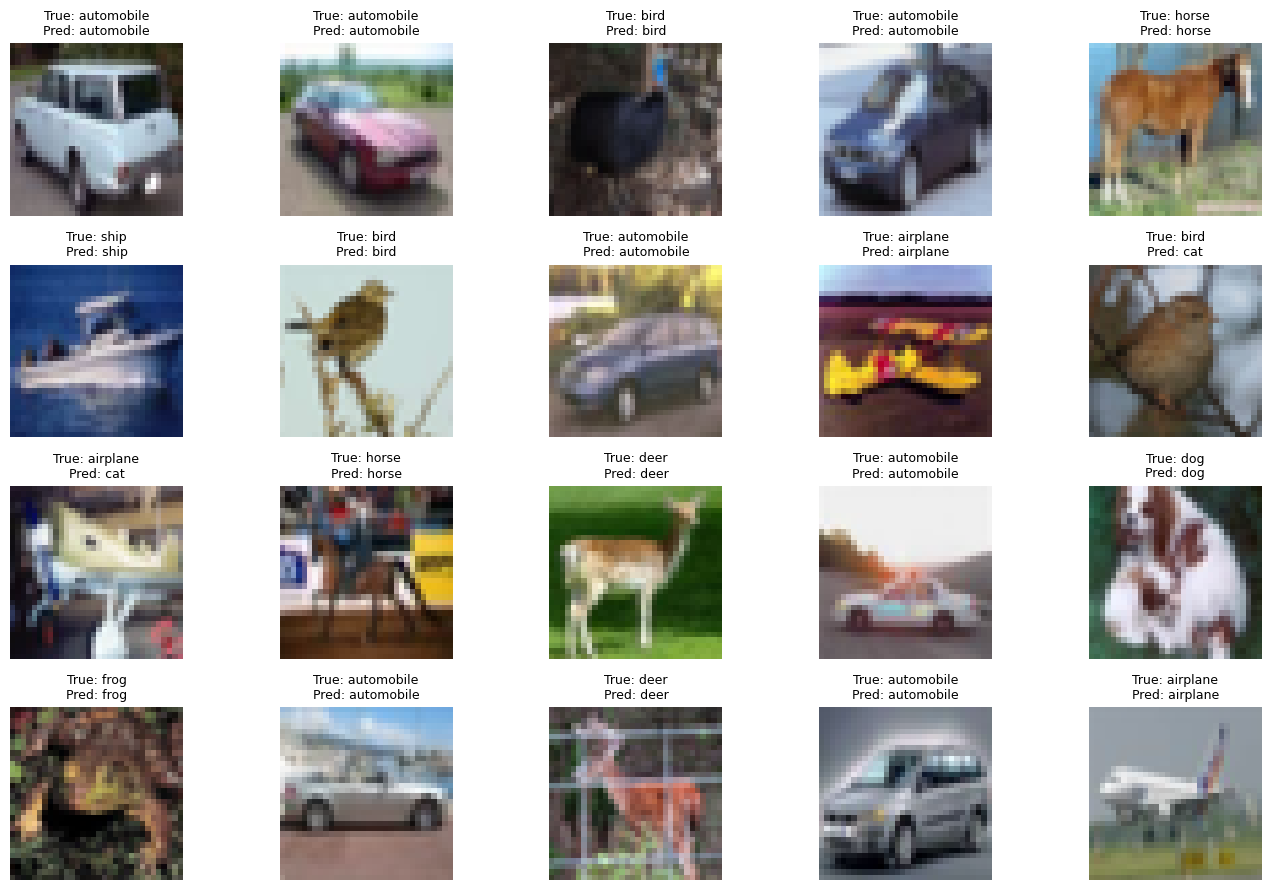

In [119]:
number_of_images = 20

random_indices = np.random.choice(
    len(x_test),
    size=number_of_images,
    replace=False
)

plt.figure(figsize=(14, 9))

for position, image_index in enumerate(random_indices):

    plt.subplot(4, 5, position + 1)

    plt.imshow(x_test[image_index])

    true_label = y_test[image_index]
    predicted_label = y_pred[image_index]

    true_class = class_names[true_label]
    predicted_class = class_names[predicted_label]

    title = f"True: {true_class}\nPred: {predicted_class}"

    plt.title(title, fontsize=9)

    plt.axis("off")

plt.tight_layout()
plt.show()

### **9.7.4 representing 20 incorrect predictions**

Number of incorrect predictions: 2104
Number of correct predictions: 7896


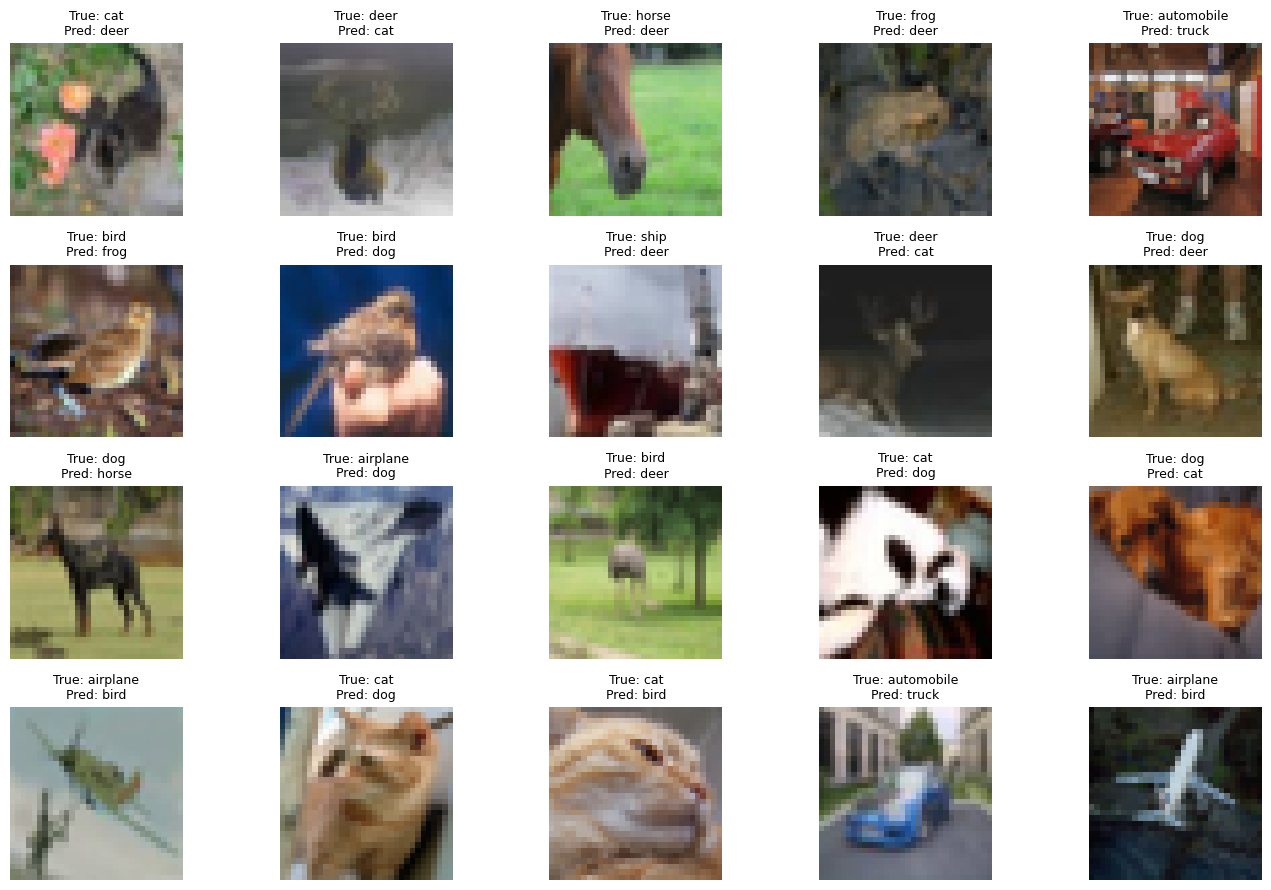

In [121]:
incorrect_indices = np.where(y_test != y_pred)[0]

print("Number of incorrect predictions:", len(incorrect_indices))
print("Number of correct predictions:", len(y_test) - len(incorrect_indices))

number_of_images = 20

sample_incorrect_indices = np.random.choice(
    incorrect_indices,
    size=number_of_images,
    replace=False
)

plt.figure(figsize=(14, 9))

for position, image_index in enumerate(sample_incorrect_indices):

    plt.subplot(4, 5, position + 1)

    plt.imshow(x_test[image_index])

    true_label = y_test[image_index]
    predicted_label = y_pred[image_index]

    true_class = class_names[true_label]
    predicted_class = class_names[predicted_label]

    title = f"True: {true_class}\nPred: {predicted_class}"

    plt.title(title, fontsize=9)

    plt.axis("off")

plt.tight_layout()
plt.show()

### **9.7.5 Saving ADAM model to drive**

In [122]:
model_save_path = "/content/drive/MyDrive/Saved Models/best_cifar10_adam_model.keras"

adam_model.save(model_save_path)

print("Best model saved to:", model_save_path)

Best model saved to: /content/drive/MyDrive/Saved Models/best_cifar10_adam_model.keras


# ***10. Autoencoder / VAE***

# ***11. Reconstruction Results***

# ***12. Generative Model***

# ***13. Generated Samples***

# ***14. Final Comparison***

# ***15. Final Reflection***